# Post process data extracted using LLMs


In [155]:
import numpy as np
import pandas as pd
import geopandas as gpd
import geopy as gpy
import time
import itertools
from matplotlib import pyplot as plt
from src.data import *
from src.plot_functions import *



In [4]:
#load data
fnout = "5labelled_response_test1.csv"
response_df = pd.read_csv(DATA_OUT_PATH+fnout)

In [5]:
response_df

,Unnamed: 0,hazardType,country,region,state,city,locationAnnotation,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardName,hazardSubtypes,appealCode,location,date,disasterType
0,0,Flood,Algeria,Southern and Western Algeria,"Béchar, Tamanrasset, El Bayadh, Tiaret, Tindou...","Béchar, Elbayadh, Beni Abbes, Tamanrasset","The most affected areas include Béchar, Elbaya...",2024,9,5,2024,9,8,NaN,[],MDRDZ011,Algeria,22/09/2024,Famine / Food Insecurity
1,1,Storm,Algeria,Southern and Western Algeria,"Béchar, Tamanrasset, El Bayadh, Tiaret, Tindou...","Béchar, Elbayadh, Beni Abbes, Tamanrasset","On September 8, 2024, a severe tropical distur...",2024,9,5,2024,9,8,NaN,"[""tropical storm""]",MDRDZ011,Algeria,22/09/2024,Famine / Food Insecurity
2,2,Mass movement,Pakistan,"Balochistan, Sindh, Punjab, Khyber Pakhtunkhwa...",NaN,"Jacobabad, Naushahro Feroz, Ghotki, Sukkur, Sa...","Areas such as Jacobabad, Naushahro Feroz, Ghot...",2024,7,1,2024,9,1,NaN,"[""landslide"", ""mudslide""]",MDRPK026,Pakistan,17/09/2024,Flood
3,3,Flood,Pakistan,"Balochistan, Sindh, Punjab, Khyber Pakhtunkhwa",NaN,"Jacobabad, Naushahro Feroz, Ghotki, Sukkur, Sa...","Areas such as Jacobabad, Naushahro Feroz, Ghot...",2024,7,1,2024,9,1,NaN,"[""flash flood"", ""riverine flood""]",MDRPK026,Pakistan,17/09/2024,Flood
4,4,Extreme temperature,Pakistan,"Balochistan, Sindh, Punjab, Khyber Pakhtunkhwa...",NaN,"Jacobabad, Naushahro Feroz, Ghotki, Sukkur, Sa...","Regionally, Balochistan received 239 per cent ...",2024,7,1,2024,9,1,NaN,[],MDRPK026,Pakistan,17/09/2024,Flood
5,5,Flood,Cameroon,Extrême-Nord,NaN,"Yagoua, Blangoua, Mackary, Zina, Maga",Cameroon's Far North region has been experienc...,2024,7,1,2024,8,28,Flood,[],MDRCM039,Cameroon,13/09/2024,Flood
6,6,Flood,Benin,Couffo,NaN,NaN,Intense rainfall observed in the departments o...,2024,6,26,2024,6,26,NaN,"[""riverine flood""]",MDRBJ019,Benin,07/09/2024,Flood
7,7,Mass movement,Sudan,NaN,"Red Sea, River Nile, Northern State",NaN,"So far, Red Sea, River Nile, and Northern Stat...",2024,6,1,2024,8,12,NaN,[],MDRSD034,Sudan,06/09/2024,Flood
8,8,Flood,Sudan,NaN,"Red Sea, River Nile, Northern State",NaN,"So far, Red Sea, River Nile, and Northern Stat...",2024,6,1,2024,8,12,NaN,"[""flash flood"", ""riverine flood""]",MDRSD034,Sudan,06/09/2024,Flood


In [ ]:
#add iso3
from src.LLM_functions import country_name_to_iso3
response_df["country_iso3"] = response_df["country"].apply(country_name_to_iso3)

In [109]:
response_df

,Unnamed: 0,hazardType,country,region,state,city,locationAnnotation,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardName,hazardSubtypes,appealCode,location,date,disasterType,country_iso3
0,0,Flood,Algeria,Southern and Western Algeria,"Béchar, Tamanrasset, El Bayadh, Tiaret, Tindou...","Béchar, Elbayadh, Beni Abbes, Tamanrasset","The most affected areas include Béchar, Elbaya...",2024,9,5,2024,9,8,NaN,[],MDRDZ011,Algeria,22/09/2024,Famine / Food Insecurity,DZA
1,1,Storm,Algeria,Southern and Western Algeria,"Béchar, Tamanrasset, El Bayadh, Tiaret, Tindou...","Béchar, Elbayadh, Beni Abbes, Tamanrasset","On September 8, 2024, a severe tropical distur...",2024,9,5,2024,9,8,NaN,"[""tropical storm""]",MDRDZ011,Algeria,22/09/2024,Famine / Food Insecurity,DZA
2,2,Mass movement,Pakistan,"Balochistan, Sindh, Punjab, Khyber Pakhtunkhwa...",NaN,"Jacobabad, Naushahro Feroz, Ghotki, Sukkur, Sa...","Areas such as Jacobabad, Naushahro Feroz, Ghot...",2024,7,1,2024,9,1,NaN,"[""landslide"", ""mudslide""]",MDRPK026,Pakistan,17/09/2024,Flood,PAK
3,3,Flood,Pakistan,"Balochistan, Sindh, Punjab, Khyber Pakhtunkhwa",NaN,"Jacobabad, Naushahro Feroz, Ghotki, Sukkur, Sa...","Areas such as Jacobabad, Naushahro Feroz, Ghot...",2024,7,1,2024,9,1,NaN,"[""flash flood"", ""riverine flood""]",MDRPK026,Pakistan,17/09/2024,Flood,PAK
4,4,Extreme temperature,Pakistan,"Balochistan, Sindh, Punjab, Khyber Pakhtunkhwa...",NaN,"Jacobabad, Naushahro Feroz, Ghotki, Sukkur, Sa...","Regionally, Balochistan received 239 per cent ...",2024,7,1,2024,9,1,NaN,[],MDRPK026,Pakistan,17/09/2024,Flood,PAK
5,5,Flood,Cameroon,Extrême-Nord,NaN,"Yagoua, Blangoua, Mackary, Zina, Maga",Cameroon's Far North region has been experienc...,2024,7,1,2024,8,28,Flood,[],MDRCM039,Cameroon,13/09/2024,Flood,CMR
6,6,Flood,Benin,Couffo,NaN,NaN,Intense rainfall observed in the departments o...,2024,6,26,2024,6,26,NaN,"[""riverine flood""]",MDRBJ019,Benin,07/09/2024,Flood,BEN
7,7,Mass movement,Sudan,NaN,"Red Sea, River Nile, Northern State",NaN,"So far, Red Sea, River Nile, and Northern Stat...",2024,6,1,2024,8,12,NaN,[],MDRSD034,Sudan,06/09/2024,Flood,SDN
8,8,Flood,Sudan,NaN,"Red Sea, River Nile, Northern State",NaN,"So far, Red Sea, River Nile, and Northern Stat...",2024,6,1,2024,8,12,NaN,"[""flash flood"", ""riverine flood""]",MDRSD034,Sudan,06/09/2024,Flood,SDN


In [164]:
def separate_locs(locations):
    if pd.isnull(locations):
        return None
    else:
        return locations.split(",")

def remove_startspace(loc_list):
    if loc_list is None:
        return None
    else:
        return [loc.strip() for loc in loc_list]

In [165]:
geolocator = gpy.geocoders.Nominatim(user_agent='luca.severino@usys.ethz.ch')
response_row = response_df.iloc[3]
country = response_row["country"]
regions = separate_locs(response_row["region"])
states = separate_locs(response_row["state"])
cities = separate_locs(response_row["city"])
df_list = []
i = 0
time_last_request = time.time()
if cities:
    finest_loc_id = "city"
    finest_loc_vals = cities
elif states:
    finest_loc_id = "state"
    finest_loc_vals = states
elif regions:
    finest_loc_id = "region"
    finest_loc_vals = regions
else:
    finest_loc_id = None
    print("No location information for response: ", response_row.appealCode)
if finest_loc_id:
    for ctry, loc in itertools.product([country], finest_loc_vals):#zip([country]*len(regions), regions, states, cities):
        nominatim_query = {
            "country": ctry,
            finest_loc_id: loc
        }
        time_new_request = time.time()
        if time_new_request - time_last_request < 1:
            time.sleep(time_new_request - time_last_request)
        nominatim_result = geolocator.geocode(nominatim_query)
        time_last_request = time_new_request
        if nominatim_result is None:
            print("No results for query: ", nominatim_query)
        else:
            nominatim_query["latitude"] = nominatim_result.latitude
            nominatim_query["longitude"] = nominatim_result.longitude
        df_list.append(pd.DataFrame(nominatim_query, index=pd.MultiIndex.from_tuples([(response_row.appealCode, i)], names=['appealCode', 'index'])))
        i+=1
    pd.concat(df_list)

No results for query:  {'country': 'Pakistan', 'city': ' Naushahro Feroz'}


KeyboardInterrupt: 

In [138]:
pd.concat(df_list)

country                  city   latitude  longitude
appealCode index                                                      
MDRPK026   0      Pakistan             Jacobabad  28.281309  68.436436
           1      Pakistan       Naushahro Feroz        NaN        NaN
           2      Pakistan                Ghotki  28.006657  69.315104
           3      Pakistan                Sukkur  27.696188  68.858875
           4      Pakistan               Sanghar  26.047045  68.949240
           5      Pakistan                  Dadu  26.727484  67.780497
           6      Pakistan   Shaheed Benazirabad        NaN        NaN
           7      Pakistan               Kashmor  28.432292  69.581475
           8      Pakistan               Chitral  35.850889  71.790190

In [166]:
#geolocate location text using nominatim
def make_nominatim_query(irow, response_row, geolocator):
    '''Function to extract geoloactions from text using nominatim'''
    country = response_row["country"]
    regions = separate_locs(response_row["region"])
    states = separate_locs(response_row["state"])
    cities = separate_locs(response_row["city"])
    regions = remove_startspace(regions)
    states = remove_startspace(states)
    cities =remove_startspace(cities)
    df_list = []
    i = 1
    if cities:
        finest_loc_id = "city"
        finest_loc_vals = cities
    elif states:
        finest_loc_id = "state"
        finest_loc_vals = states
    elif regions:
        finest_loc_id = "region"
        finest_loc_vals = regions
    else:
        finest_loc_id = None
    print("No location information for response: ", response_row.appealCode)

    if finest_loc_id:
        time_last_request = time.time()
        for ctry, loc in itertools.product([country], finest_loc_vals):#zip([country]*len(regions), regions, states, cities):
            nominatim_query = {
                "country": ctry,
                finest_loc_id: loc
            }

            time_new_request = time.time()
            if time_new_request - time_last_request < 1:
                time.sleep(time_new_request - time_last_request)
            nominatim_result = geolocator.geocode(nominatim_query)
            time_last_request = time_new_request
            if nominatim_result is None:
                print("No results for query: ", nominatim_query)
                continue
            else:
                nominatim_query["latitude"] = nominatim_result.latitude
                nominatim_query["longitude"] = nominatim_result.longitude
                df_list.append(pd.DataFrame(nominatim_query, index=pd.MultiIndex.from_tuples([(response_row.appealCode, irow+i+1)], names=['appealCode', 'index'])))
            i+=1

    return df_list

In [167]:
list_all_locs = []
for i, row in response_df.iterrows():
    loc_list = make_nominatim_query(i, row, geolocator)
    if loc_list:
        list_all_locs.extend(loc_list)
    else:
        print(f"No results for row: {i}, appealCode: {row['appealCode']}")
df_all_locs = pd.concat(list_all_locs)

No location information for response:  MDRDZ011
No results for query:  {'country': 'Algeria', 'city': 'Elbayadh'}
No location information for response:  MDRDZ011
No results for query:  {'country': 'Algeria', 'city': 'Elbayadh'}
No location information for response:  MDRPK026
No results for query:  {'country': 'Pakistan', 'city': 'Naushahro Feroz'}
No results for query:  {'country': 'Pakistan', 'city': 'Shaheed Benazirabad'}
No location information for response:  MDRPK026
No results for query:  {'country': 'Pakistan', 'city': 'Naushahro Feroz'}
No results for query:  {'country': 'Pakistan', 'city': 'Shaheed Benazirabad'}
No location information for response:  MDRPK026
No results for query:  {'country': 'Pakistan', 'city': 'Naushahro Feroz'}
No results for query:  {'country': 'Pakistan', 'city': 'Shaheed Benazirabad'}
No location information for response:  MDRCM039
No results for query:  {'country': 'Cameroon', 'city': 'Mackary'}
No location information for response:  MDRBJ019
No locatio

In [171]:
df_all_locs

AttributeError: 'NoneType' object has no attribute 'copy'

country         city   latitude  longitude  region  \
appealCode index                                                        
MDRDZ011   2       Algeria       Béchar  31.616312  -2.218410     NaN   
           3       Algeria   Beni Abbes  30.131743  -2.169031     NaN   
           4       Algeria  Tamanrasset  22.785937   5.529140     NaN   
           3       Algeria       Béchar  31.616312  -2.218410     NaN   
           4       Algeria   Beni Abbes  30.131743  -2.169031     NaN   
           5       Algeria  Tamanrasset  22.785937   5.529140     NaN   
MDRPK026   4      Pakistan    Jacobabad  28.281309  68.436436     NaN   
           5      Pakistan       Ghotki  28.006657  69.315104     NaN   
           6      Pakistan       Sukkur  27.696188  68.858875     NaN   
           7      Pakistan      Sanghar  26.047045  68.949240     NaN   
           8      Pakistan         Dadu  26.727484  67.780497     NaN   
           9      Pakistan      Kashmor  28.432292  69.581475     NaN   
           10     Pakistan   Tando Adam  25.762095  68.657808     NaN   
           5      Pakistan    Jacobabad  28.281309  68.436436     NaN   
           6      Pakistan       Ghotki  28.006657  69.315104     NaN   
           7      Pakistan       Sukkur  27.696188  68.858875     NaN   
           8      Pakistan      Sanghar  26.047045  68.949240     NaN   
           9      Pakistan         Dadu  26.727484  67.780497     NaN   
           10     Pakistan      Kashmor  28.432292  69.581475     NaN   
           11     Pakistan      Chitral  35.850889  71.790190     NaN   
           6      Pakistan    Jacobabad  28.281309  68.436436     NaN   
           7      Pakistan       Ghotki  28.006657  69.315104     NaN   
           8      Pakistan       Sukkur  27.696188  68.858875     NaN   
           9      Pakistan      Sanghar  26.047045  68.949240     NaN   
           10     Pakistan         Dadu  26.727484  67.780497     NaN   
           11     Pakistan      Kashmor  28.432292  69.581475     NaN   
MDRCM039   7      Cameroon       Yagoua  10.344430  15.226587     NaN   
           8      Cameroon     Blangoua  12.773962  14.552517     NaN   
           9      Cameroon         Zina  11.263815  14.964830     NaN   
           10     Cameroon         Maga  10.841601  14.952686     NaN   
MDRBJ019   8         Benin          NaN   9.529347   2.258441  Couffo   
MDRSD034   9         Sudan          NaN  17.998493  34.055823     NaN   
           10        Sudan          NaN  19.000000  30.000000     NaN   
           10        Sudan          NaN  17.998493  34.055823     NaN   
           11        Sudan          NaN  19.000000  30.000000     NaN   

                           state                   geometry  
appealCode index                                             
MDRDZ011   2                 NaN  POINT (-2.21841 31.61631)  
           3                 NaN  POINT (-2.16903 30.13174)  
           4                 NaN   POINT (5.52914 22.78594)  
           3                 NaN  POINT (-2.21841 31.61631)  
           4                 NaN  POINT (-2.16903 30.13174)  
           5                 NaN   POINT (5.52914 22.78594)  
MDRPK026   4                 NaN  POINT (68.43644 28.28131)  
           5                 NaN  POINT (69.31510 28.00666)  
           6                 NaN  POINT (68.85888 27.69619)  
           7                 NaN  POINT (68.94924 26.04704)  
           8                 NaN  POINT (67.78050 26.72748)  
           9                 NaN  POINT (69.58148 28.43229)  
           10                NaN  POINT (68.65781 25.76210)  
           5                 NaN  POINT (68.43644 28.28131)  
           6                 NaN  POINT (69.31510 28.00666)  
           7                 NaN  POINT (68.85888 27.69619)  
           8                 NaN  POINT (68.94924 26.04704)  
           9                 NaN  POINT (67.78050 26.72748)  
           10                NaN  POINT (69.58148 28.43229)  
           11  

In [169]:
df_all_locs = gpd.GeoDataFrame(df_all_locs, geometry=gpd.points_from_xy(df_all_locs.longitude, df_all_locs.latitude))

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_46639/1380495779.py:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


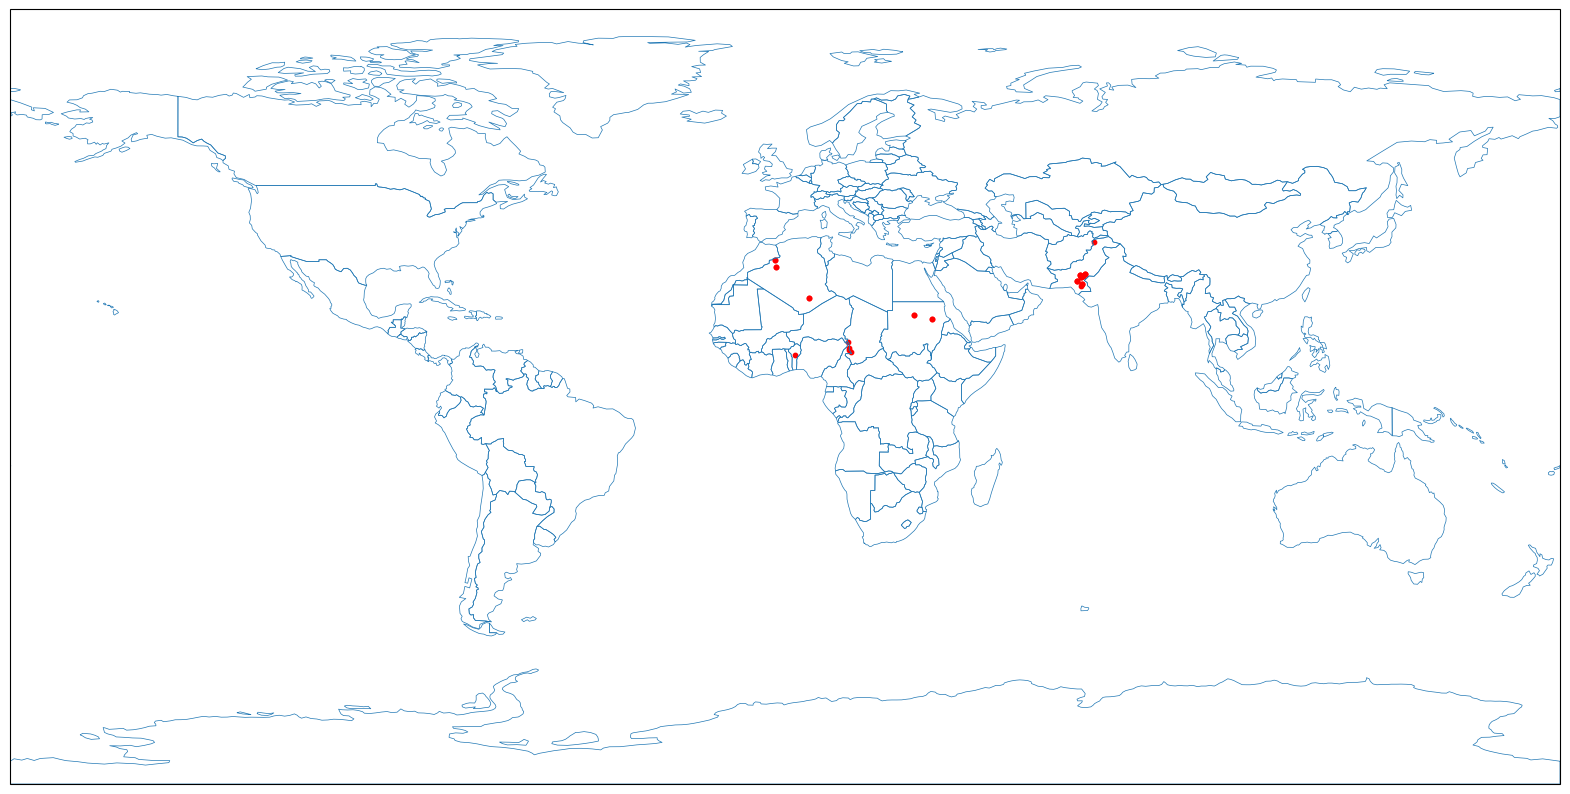

In [170]:
f, axes = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.PlateCarree()),figsize=(20, 20))
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world.boundary.plot(ax=axes, linewidth=0.5)
df_all_locs.plot(ax=axes, color='red', markersize=10)
plt.show()
